# 08. Квантовый классификатор (Qiskit)

## Сжатие входа: PCA(4) = 4 кубита

Сырые табличные признаки (после масштабирования) проектируются в **4 главные компоненты** — ровно под размер `ZZFeatureMap`. Это компромисс: часть дисперсии выбрасывается, зато схема укладывается в малый число кубитов для симуляции.

In [1]:
from pathlib import Path
import sys
import os

for _p in (Path.cwd(), Path.cwd().parent):
    if (_p / "src" / "helpers.py").is_file():
        sys.path.insert(0, str((_p / "src").resolve()))
        os.chdir(_p)
        break

In [ ]:
from helpers import init_notebook_path, ensure_dirs, PROJECT_ROOT, PLOT_DIR, DATA_DIR, RANDOM_STATE
ROOT = init_notebook_path()
ensure_dirs()
print("PROJECT_ROOT", PROJECT_ROOT)

In [ ]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_machine_learning.algorithms.classifiers import VQC
from qiskit_machine_learning.optimizers import SciPyOptimizer
from qiskit_aer.primitives import Sampler as AerSampler
from helpers import load_xy_from_processed, classification_metrics_dict, print_report, append_metrics_store, PLOT_DIR, CLASS_NAMES, RANDOM_STATE

In [4]:
X_train, X_val, X_test, y_train, y_val, y_test, _ = load_xy_from_processed()
n_qubits = 4
pca = PCA(n_components=n_qubits, random_state=RANDOM_STATE)
Xt = pca.fit_transform(X_train)
Xte = pca.transform(X_test)
n_classes = len(CLASS_NAMES)


In [5]:
N_MAXITER = 400
_tqdm_w = int(os.environ.get("COLUMNS", 0) or 0) or max(shutil.get_terminal_size(fallback=(200, 1)).columns, 160)
pbar = tqdm(
    desc="VQC loss (COBYLA)",
    unit="ev",
    mininterval=0.2,
    ncols=_tqdm_w,
    dynamic_ncols=True,
        bar_format="{l_bar}{bar}{r_bar}",
)

VQC loss (COBYLA): |                                                                                          …

In [6]:
def ang(z):
    z = np.clip(z, -3, 3)
    return z * np.pi / 3.0

def vqc_pbar(_w, loss):
    pbar.set_postfix_str(f" L={loss:.5f} ", refresh=True)
    pbar.update(1)


## Обязательно: `output_shape` = числу классов

По умолчанию VQC в Qiskit Machine Learning ориентирована на **два** выхода, если не указать `output_shape=len(CLASS_NAMES)`. Без **четырёх** исходов `argmax` на выходе даёт только метки 0/1, и **береговые** классы в предсказаниях не появляются, даже если `y_test` сбалансирован.

## Подвыборка, оптимизатор, прогресс

- Обучающий набор можно ограничить `sub` из соображений времени; **стратифицированный** отбор (`stratify`) сохраняет доли классов в подвыборке, в отличие от простого `[:sub]`.  
- Оптимизатор: COBYLA через `SciPyOptimizer` из `qiskit_machine_learning`, чтобы `callback(веса, loss)` корректно вызывался при обучении.  
- Полоса `tqdm` — по числу оценок loss (не «один тик = одна эпоха нейросети»).

In [7]:
Xt, Xte = ang(Xt), ang(Xte)
fm = ZZFeatureMap(feature_dimension=n_qubits, reps=2)
ans = RealAmplitudes(num_qubits=n_qubits, reps=3)

vqc = VQC(
    feature_map=fm,
    ansatz=ans,
    loss="cross_entropy",
    optimizer=SciPyOptimizer("COBYLA", options={"maxiter": N_MAXITER}),
    sampler=AerSampler(run_options={"method": "statevector", "shots": None}),
    callback=vqc_pbar,
    output_shape=n_classes,
)

pbar = tqdm(
    desc="VQC loss (COBYLA)",
    unit="ev",
    mininterval=0.2,
    ncols=_tqdm_w,
    dynamic_ncols=True,
        bar_format="{l_bar}{bar}{r_bar}",
)

sub = min(3000, len(Xt))
if sub < len(Xt):
    Xt_fit, _, y_fit, _ = train_test_split(
        Xt, y_train, train_size=sub, random_state=RANDOM_STATE, stratify=y_train
    )
else:
    Xt_fit, y_fit = Xt, y_train
print("VQC: n =", len(y_fit), "классы =", np.bincount(y_fit.astype(int), minlength=n_classes))
try:
    vqc.fit(Xt_fit, y_fit)
finally:
    pbar.close()

VQC loss (COBYLA): |                                                                                          …

VQC: n = 3000 классы = [750 750 750 750]


In [8]:
y_pred = vqc.predict(Xte)
m = classification_metrics_dict(y_test, y_pred)
print(m)
print_report(y_test, y_pred)

{'accuracy': 0.2991666666666667, 'precision_macro': 0.29952533620672034, 'recall_macro': 0.2991666666666667, 'f1_macro': 0.29690327557665314, 'precision_micro': 0.2991666666666667, 'recall_micro': 0.2991666666666667, 'f1_micro': 0.2991666666666667}
              precision    recall  f1-score   support

    OPEN_SEA       0.35      0.39      0.36       300
 COASTAL_SEA       0.28      0.33      0.30       300
  NEAR_COAST       0.26      0.25      0.26       300
   COASTLINE       0.32      0.23      0.27       300

    accuracy                           0.30      1200
   macro avg       0.30      0.30      0.30      1200
weighted avg       0.30      0.30      0.30      1200



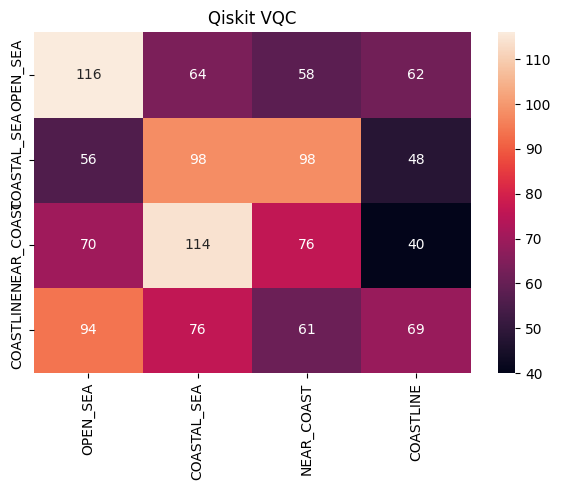

In [9]:
append_metrics_store('qiskit_vqc', m)
cm = confusion_matrix(y_test, y_pred, labels=np.arange(len(CLASS_NAMES)))

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Qiskit VQC')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'confusion_qiskit.png', dpi=150)
plt.show()
plt.close()
